<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Proyecto02-Grupo1-jc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 2 - Machine Learning

## 1. Portada

**Proyecto:**  Detección de Fraudes Transaccionales

**Programa:** Maestría en Ciencia de Datos & Inteligencia Artificial

**Curso:** MDC8010 - Machine Learning

**Integrantes Grupo 1:**    
- Alejandro Pinedo  
- David Jimenez  
- José Carlos Nomberto

**Fecha de Entrega:** 25 de Marzo, 2026

## 2. Introducción

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de identificar transacciones fraudulentas a partir de un conjunto de datos altamente desbalanceado (aproximadamente 3.5% de fraude). El dataset proporcionado (basado en IEEE-CIS Fraud Detection) contiene cientos de variables continuas y categóricas.

Para abordar este desafío y maximizar el **F1-Score** a estándares industriales, evolucionaremos desde un modelo base lineal hacia estrategias avanzadas de preprocesamiento:
- Implementaremos ingeniería de características temporales y de frecuencia
- Clustering (MiniBatchKMeans) para la macro-segmentación comportamental y reducción de dimensionalidad (PCA) enfocada en la intrincada colinealidad de las variables *V- features*
- Construiremos un modelo **LightGBM** (manejando naturalmente el desbalance y la escasez de datos) aplicando Post-Optimización para detectar el umbral exacto de decisión que dispara nuestra recuperación de fraudes sin sacrificar indiscriminadamente la precisión.



## 3. Análisis Exploratorio de Datos (EDA)





Cargue y optimice el uso de memoria de los conjuntos de datos 'train_transaction.csv' y 'train_identity.csv', y luego combínelos basándose en 'TransactionID'. Posteriormente, realice un análisis descriptivo inicial del conjunto de datos combinado, incluyendo su forma, tipos de datos, valores nulos, resúmenes estadísticos y el porcentaje de transacciones fraudulentas. Finalmente, guarde los datos preprocesados ​​en un formato eficiente, como Parquet.

### 3.1. Carga y Descripción del Dataset



El dataset IEEE-CIS Fraud Detection fue proporcionado por Vesta Corporation y contiene transacciones de comercio electrónico. Se compone de dos archivos:
- train transaction.csv: 590,540 filas × 394 columnas (25.5MB).
- train identity.csv: 144,233 filas × 41 columnas (683.4 MB).

Los archivos se relacionan
mediante la columna TransactionID.

Dado el inmenso tamaño del dataset, cargaremos los datos aplicando una reducción de su huella en memoria, transformando los tipos *float64* e *int64* en alternativas más ligeras como por ejemplo: *float64* a *float32*, *int64* a *int32/int16/int8* según corresponda.

In [1]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
def reduce_mem_usage(df):
    """
    Itera a través de todas las columnas de un dataframe y modifica el tipo de dato
    para reducir el uso de memoria.
    """

    start_mem = df.memory_usage().sum() / 1024**2
    # if verbose:
    #     print(f'Uso de memoria inicial del dataframe: {start_mem:.2f} MB')
    print(f'Uso de memoria inicial del dataframe: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    # if verbose:
    #     print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
    #     print(f'Memoria reducida en: {(100 * (start_mem - end_mem) / start_mem):.2f}%')
    print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
    print(f'Memoria reducida en: {(100 * (start_mem - end_mem) / start_mem):.2f}%')

    return df

print("Función 'reduce_mem_usage' definida.")

Función 'reduce_mem_usage' definida.


Carga y optimización de dataset 'train_transaction.csv'



In [3]:
print("Cargando 'train_transaction.csv' y optimizando su uso de memoria...")
df_train_transaction = pd.read_csv('train_transaction.csv')
df_train_transaction = reduce_mem_usage(df_train_transaction)
print("DataFrame 'df_train_transaction' cargado y optimizado.")
df_train_transaction.head()

Cargando 'train_transaction.csv' y optimizando su uso de memoria...
Uso de memoria inicial del dataframe: 1775.15 MB
Uso de memoria después de la optimización: 487.16 MB
Memoria reducida en: 72.56%
DataFrame 'df_train_transaction' cargado y optimizado.


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Carga y optimización de dataset 'train_identity.csv'



In [4]:
print("Cargando 'train_identity.csv' y optimizando su uso de memoria...")
df_train_identity = pd.read_csv('train_identity.csv')
df_train_identity = reduce_mem_usage(df_train_identity)
print("DataFrame 'df_train_identity' cargado y optimizado.")
df_train_identity.head()

Cargando 'train_identity.csv' y optimizando su uso de memoria...
Uso de memoria inicial del dataframe: 45.12 MB
Uso de memoria después de la optimización: 10.00 MB
Memoria reducida en: 77.84%
DataFrame 'df_train_identity' cargado y optimizado.


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


Crear el dataset completo uniendo los dos dataset originales con un
LEFT JOIN usando TransactionID

In [5]:
print("Fusionando 'df_train_transaction' y 'df_train_identity' en base a 'TransactionID'...")
df_train = pd.merge(df_train_transaction, df_train_identity, on='TransactionID', how='left')
print(f"DataFrames fusionados. Forma del nuevo DataFrame (df_train): {df_train.shape}")

Fusionando 'df_train_transaction' y 'df_train_identity' en base a 'TransactionID'...
DataFrames fusionados. Forma del nuevo DataFrame (df_train): (590540, 434)


Mostrar cabecera de dataset unificado `df_train`.


In [6]:
print("Mostrando las primeras 5 filas del DataFrame fusionado (df_train):")
display(df_train.head())

Mostrando las primeras 5 filas del DataFrame fusionado (df_train):


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Mostrar los tipos de datos y los valores no nulos del DataFrame combinado utilizando  para comprender su estructura e identificar posibles problemas.



In [7]:
print("Mostrando información general del DataFrame fusionado (tipos de datos y valores no nulos):")
df_train.info()

Mostrando información general del DataFrame fusionado (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: category(31), float16(354), float32(45), int16(1), int32(2), int8(1)
memory usage: 525.6 MB


Mostrar resumen estadístico de las columnas numéricas para obtener una vista de la distribución de los datos.


In [8]:
print("Mostrando el resumen estadístico de las columnas numéricas de df_train:")
display(df_train.describe())

Mostrando el resumen estadístico de las columnas numéricas de df_train:


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.0,588975.0,586281.0,524834.0,524834.0,...,139369.0,4.511300e+04,139318.0,139261.0,5159.00,5169.000000,4747.000000,5132.0000,5163.00000,77586.0
mean,3.282270e+06,0.034990,7.372311e+06,NaN,9898.734658,NaN,NaN,NaN,NaN,NaN,...,NaN,inf,NaN,NaN,inf,inf,12.820312,inf,inf,NaN
std,1.704744e+05,0.183755,4.617224e+06,0.000000,4901.170153,0.0,0.0,0.0,0.0,0.0,...,0.0,1.561523e+00,0.0,0.0,198.75,6.898438,2.373047,97.4375,32.09375,0.0
min,2.987000e+06,0.000000,8.640000e+04,0.250977,1000.000000,100.0,100.0,100.0,100.0,10.0,...,100.0,1.000000e+01,100.0,100.0,100.00,10.000000,11.000000,100.0000,100.00000,0.0
25%,3.134635e+06,0.000000,3.027058e+06,43.312500,6019.000000,214.0,150.0,166.0,204.0,87.0,...,166.0,1.300000e+01,266.0,256.0,252.00,14.000000,11.000000,321.0000,119.00000,24.0
50%,3.282270e+06,0.000000,7.306528e+06,68.750000,9678.000000,361.0,150.0,226.0,299.0,87.0,...,166.0,1.500000e+01,341.0,472.0,252.00,14.000000,11.000000,321.0000,149.00000,24.0
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.0,150.0,226.0,330.0,87.0,...,225.0,1.500000e+01,427.0,533.0,486.50,14.000000,15.000000,371.0000,169.00000,32.0
max,3.577539e+06,1.000000,1.581113e+07,31936.000000,18396.000000,600.0,231.0,237.0,540.0,102.0,...,229.0,2.900000e+01,671.0,661.0,854.00,44.000000,26.000000,548.0000,216.00000,32.0


### 3.2. Estadísticas descriptivas, distribuciones y visualizaciones


#### Tareas

- Genere un mapa de calor (heatmap) o un gráfico similar para visualizar la distribución de los valores nulos, centrándose en aquellas columnas que presenten altos porcentajes de datos faltantes.
- Calcule y visualice una matriz de correlación para las características numéricas —incluyendo 'isFraud'— con el objetivo de identificar relaciones lineales.
- Proporcione un resumen de los hallazgos clave derivados de este análisis exploratorio de datos, abarcando las distribuciones, las relaciones y los patrones iniciales de fraude.

#### Separar Características por Tipo

Identificar y clasificar las columnas del DataFrame en numéricas y categóricas para facilitar un análisis y visualización estructurados, excluyendo 'TransactionID' e 'isFraud' para la clasificación inicial.


In [9]:
print("Clasificando columnas en numéricas y categóricas...")
numerical_cols = []
categorical_cols = []

# Excluir 'TransactionID' y 'isFraud' de la clasificación
excluded_cols = ['TransactionID', 'isFraud']

for col in df_train.columns:
    if col in excluded_cols:
        continue
    if df_train[col].dtype == 'object' or df_train[col].dtype == 'category':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print(f"Total de columnas numéricas encontradas: {len(numerical_cols)}")
print(f"Primeras 5 columnas numéricas: {numerical_cols[:5]}")
print(f"Total de columnas categóricas encontradas: {len(categorical_cols)}")
print(f"Primeras 5 columnas categóricas: {categorical_cols[:5]}")

Clasificando columnas en numéricas y categóricas...
Total de columnas numéricas encontradas: 401
Primeras 5 columnas numéricas: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3']
Total de columnas categóricas encontradas: 31
Primeras 5 columnas categóricas: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


#### Visualizar distribución de variable objetico 'isFraud'

Mostrar y validar el porcentaje de transacciones fraudulentas.



In [10]:
print("Calculando el porcentaje de transacciones fraudulentas:")
fraud_percentage = (df_train['isFraud'].sum() / len(df_train)) * 100
print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.2f}%")

Calculando el porcentaje de transacciones fraudulentas:
Porcentaje de transacciones fraudulentas: 3.50%




Generar un gráfico de barras para visualizar la distribución de la variable objetivo 'isFraud', confirmando el desbalance de clases y documentando el porcentaje de cada clase. Incluirá la visualización del porcentaje de transacciones fraudulentas.


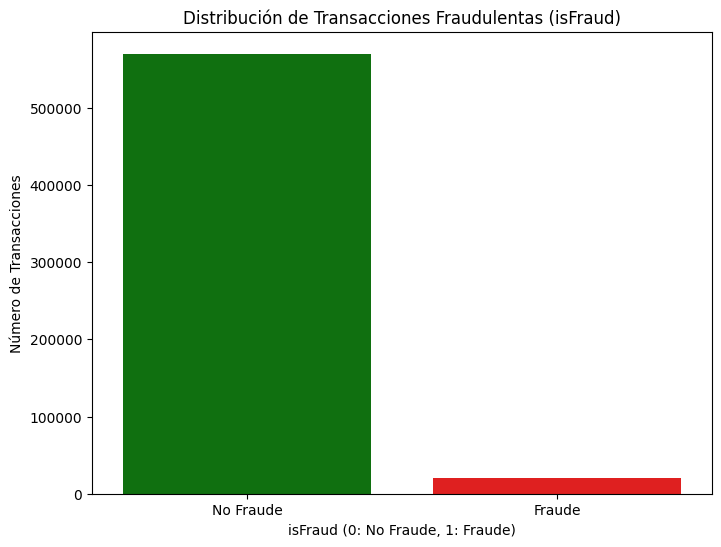

Porcentaje de transacciones fraudulentas: 3.50%


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='isFraud', data=df_train, hue='isFraud', palette=custom_palette, legend=False)
plt.title('Distribución de Transacciones Fraudulentas (isFraud)')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('Número de Transacciones')
plt.xticks([0, 1], ['No Fraude', 'Fraude'])
plt.show()

print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.2f}%")

#### Visualizar distribución de Características Numéricas Clave

Visualizar la distribución de características numéricas importantes como 'TransactionAmt' y 'TransactionDT' mediante histogramas o gráficos de densidad. Además, se explorará cómo estas distribuciones varían entre transacciones fraudulentas y no fraudulentas usando gráficos de violín o box plots.


Visualización de la distribución de 'TransactionAmt

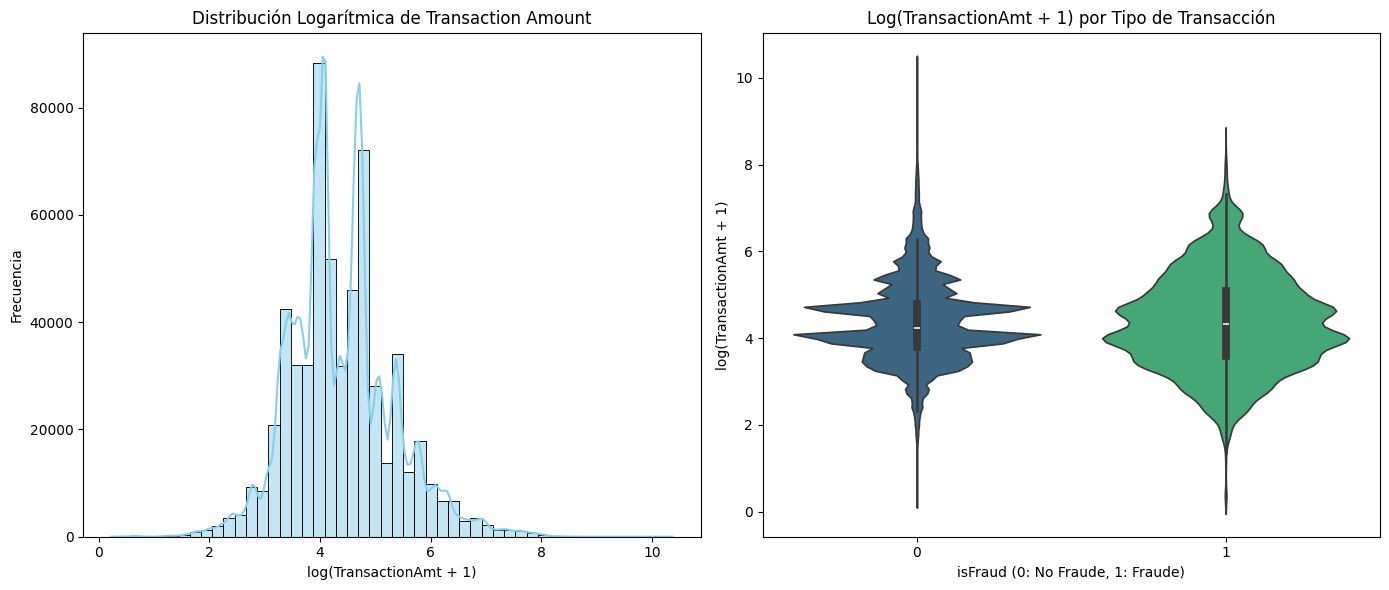

In [12]:
# 1. Visualización para 'TransactionAmt'
plt.figure(figsize=(14, 6))

# Histograma de TransactionAmt (con transformación logarítmica para mejor visualización)
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df_train['TransactionAmt']), bins=50, kde=True, color='skyblue')
plt.title('Distribución Logarítmica de Transaction Amount')
plt.xlabel('log(TransactionAmt + 1)')
plt.ylabel('Frecuencia')

# Violin plot de TransactionAmt vs isFraud
plt.subplot(1, 2, 2)
sns.violinplot(x='isFraud', y=np.log1p(df_train['TransactionAmt']), data=df_train, palette='viridis')
plt.title('Log(TransactionAmt + 1) por Tipo de Transacción')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('log(TransactionAmt + 1)')
plt.tight_layout()
plt.show()

Visualización de la distribución de 'TransactionDT

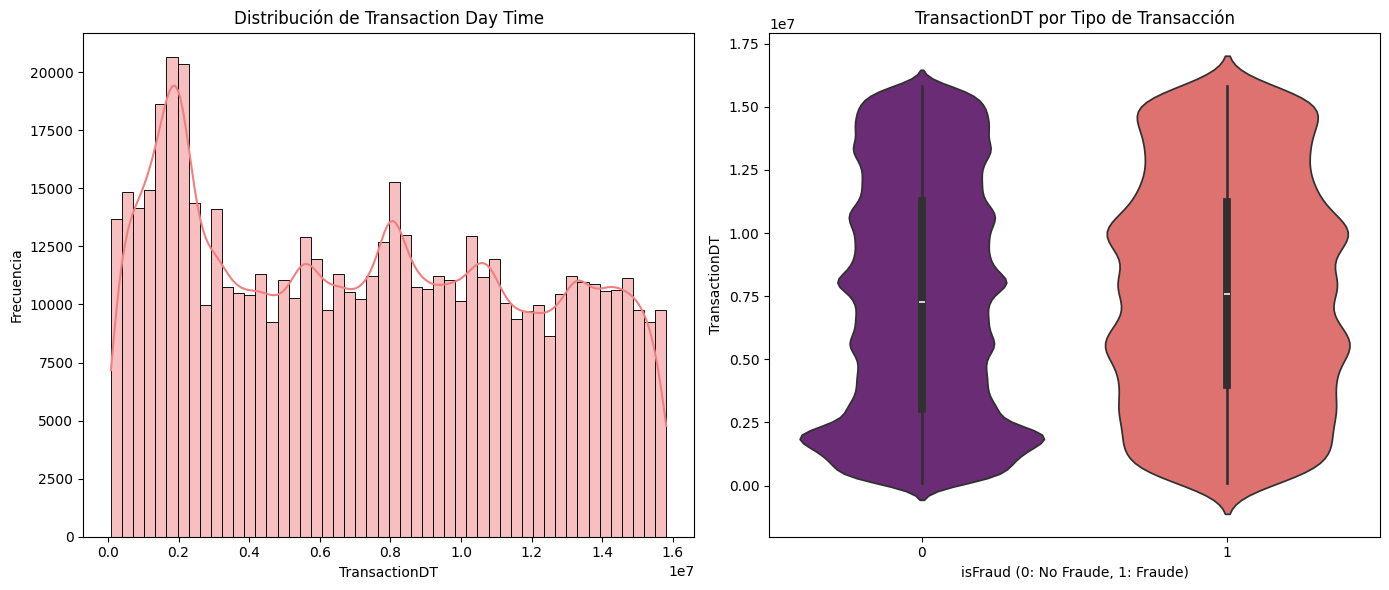

In [13]:
# 2. Visualización para 'TransactionDT'
plt.figure(figsize=(14, 6))

# Histograma de TransactionDT
plt.subplot(1, 2, 1)
sns.histplot(df_train['TransactionDT'], bins=50, kde=True, color='lightcoral')
plt.title('Distribución de Transaction Day Time')
plt.xlabel('TransactionDT')
plt.ylabel('Frecuencia')

# Violin plot de TransactionDT vs isFraud
plt.subplot(1, 2, 2)
sns.violinplot(x='isFraud', y=df_train['TransactionDT'], data=df_train, hue='isFraud', palette='magma', legend=False)
plt.title('TransactionDT por Tipo de Transacción')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('TransactionDT')
plt.tight_layout()
plt.show()

#### Distribución de Características Categóricas Clave

Crear gráficos de barras para las características categóricas relevantes como 'ProductCD', 'card4', 'card6' y 'M4' para observar sus distribuciones por categoría, diferenciando por 'isFraud' para entender los patrones de fraude.

Visualizando la distribución de 'ProductCD' por 'isFraud'

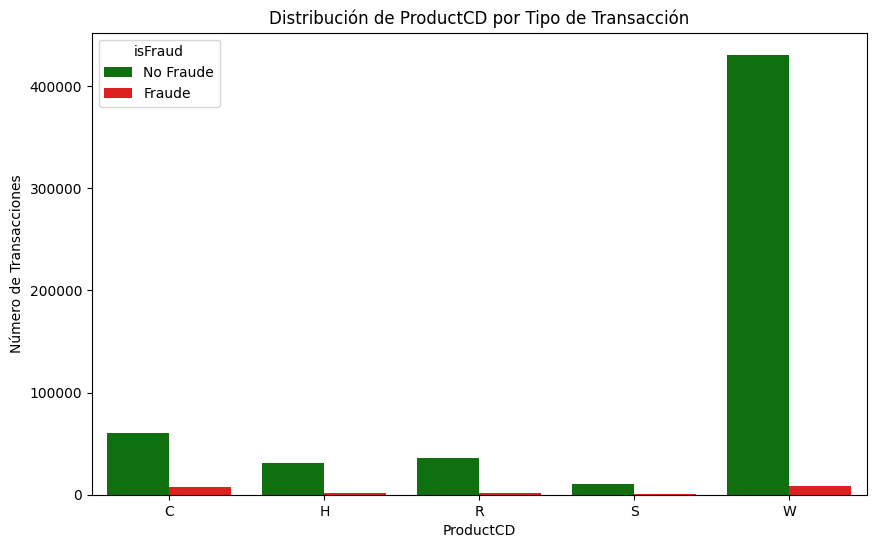

In [14]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='ProductCD', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de ProductCD por Tipo de Transacción')
plt.xlabel('ProductCD')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'card4' por 'isFraud'.



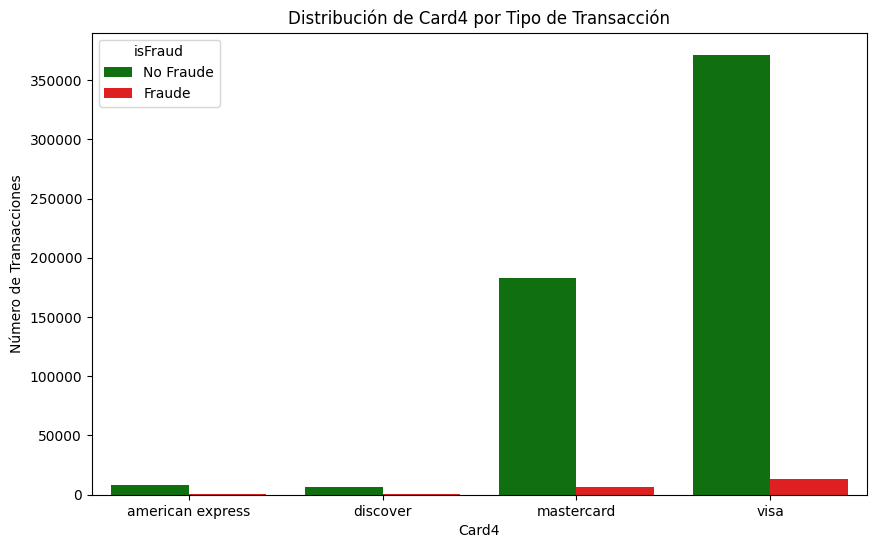

In [15]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='card4', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de Card4 por Tipo de Transacción')
plt.xlabel('Card4')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'card6' por 'isFraud'.




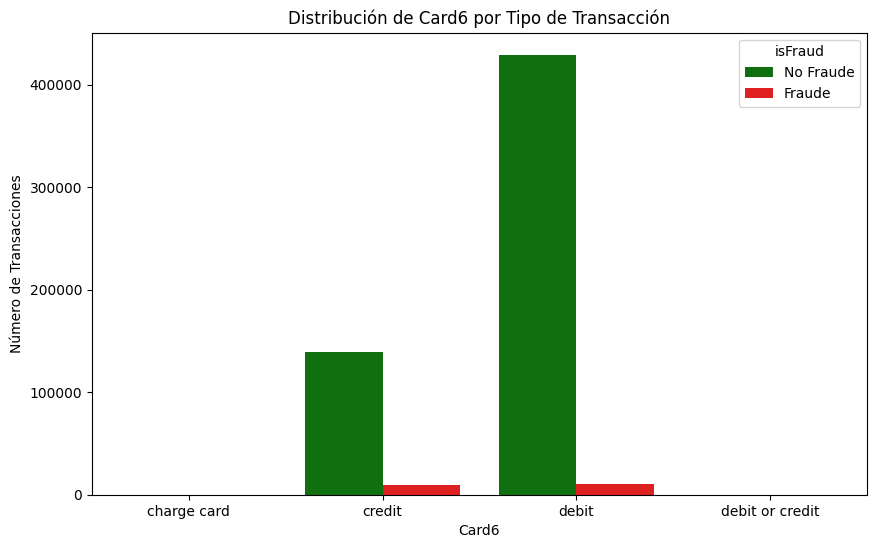

In [16]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='card6', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de Card6 por Tipo de Transacción')
plt.xlabel('Card6')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'M4' por 'isFraud'.




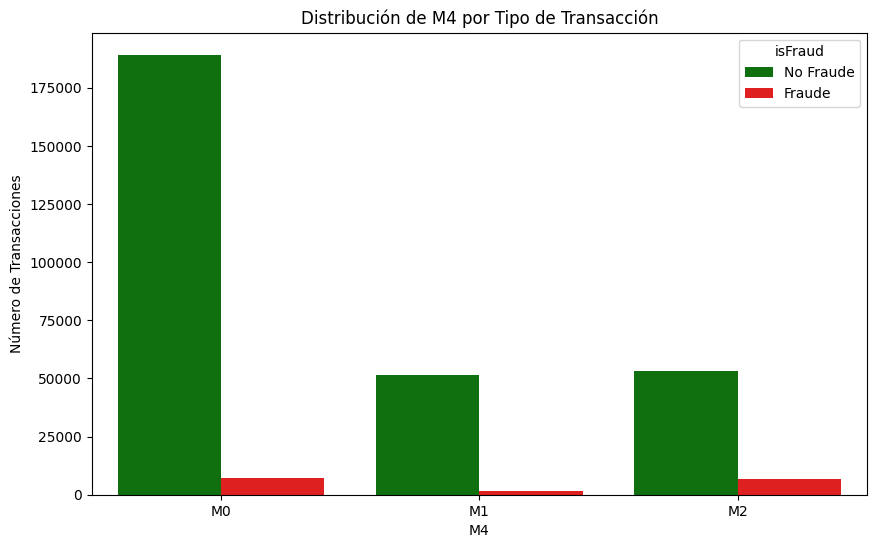

In [17]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='M4', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de M4 por Tipo de Transacción')
plt.xlabel('M4')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

#### Matriz de Correlación

Calcular y visualizar una matriz de correlación para las características numéricas, incluyendo la variable objetivo 'isFraud', para identificar posibles relaciones lineales entre las variables y con el fraude.

In [18]:
# Seleccionar solo las columnas numéricas y 'isFraud'
numerical_features_with_fraud = numerical_cols + ['isFraud']
df_numerical = df_train[numerical_features_with_fraud]

In [ ]:
# Seleccionar solo las columnas numéricas y 'isFraud'
numerical_features_with_fraud = numerical_cols + ['isFraud']
df_numerical = df_train[numerical_features_with_fraud]

# Calcular la matriz de correlación
correlation_matrix = df_numerical.corr()

# 5.2 Extraer las correlaciones con la columna 'isFraud'
isFraud_correlation = correlation_matrix['isFraud'].sort_values(ascending=False)
index_isFraud_correlation = isFraud_correlation.index.tolist()

# 5.3 Calcular la matriz de correlación ordenada con isFraud
correlation_matrix_sorted = df_numerical[index_isFraud_correlation].corr()

# 5.4 Crear un gráfico de mapa de calor
#plt.figure(figsize=(12, 8))
#sns.heatmap(matriz_correlacion_ordenada, annot=True, annot_kws={"fontsize": 8}, cmap='coolwarm', fmt=".2f", linewidths=.5)
#plt.title('Matriz de Correlación de variables correlacionadas con isFraud')
#plt.show()
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix_sorted, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Matriz de Correlación de Características Numéricas e isFraud')
plt.show()

Visualizar la distribución de Correlacion con isFraud

In [ ]:
# Histograma de Correlacion con isFraud
plt.figure(figsize=(20, 18))
sns.histplot(isFraud_correlation.drop('isFraud'), bins=50, kde=True, color='lightcoral')
plt.title('Distribución de Correlacción con isFraud')
plt.xlabel('Correlación con isFraud')
plt.ylabel('Frecuencia')


In [ ]:
isFraud_correlation.drop('isFraud').head(20)

### 3.3. Tratamiento de Valores Faltantes y Atípicos



Calcular y mostrar el porcentaje de valores nulos para cada columna en el DataFrame combinado `df_train`, ordenándolos de forma descendente para identificar rápidamente las columnas con información faltante significativa.



In [20]:
print("Calculando el porcentaje de valores nulos por columna en df_train:")
missing_values = df_train.isnull().sum()
missing_percent = 100 * missing_values / len(df_train)
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print(f"Cantidad de variables con Missing_Percentage > 85: {len(missing_df[missing_df['Missing Count'] > 80])}")
print("Top 20 variables con mayor Missing_Percentage")
display(missing_df.head(20))


Calculando el porcentaje de valores nulos por columna en df_train:
Cantidad de variables con Missing_Percentage > 85: 382
Top 20 variables con mayor Missing_Percentage


,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_23,585371,99.124699
id_22,585371,99.124699
id_27,585371,99.124699
dist2,552913,93.628374


Generarar un heatmap o un gráfico similar para visualizar la distribución de valores nulos en el DataFrame `df_train`, enfocándose especialmente en las columnas con un alto porcentaje de datos faltantes para identificar patrones de incompletitud de datos.

In [21]:
print("Generando heatmap de valores nulos para columnas con alto porcentaje de missings...")

# Filtrar columnas con más del 80% de valores nulos
missing_threshold = 80
high_missing_cols = missing_df[missing_df['Missing Percentage'] > missing_threshold].index.tolist()

# Crear un DataFrame booleano para los valores nulos de estas columnas
df_high_missing_nulls = df_train[high_missing_cols].isnull()

#plt.figure(figsize=(20, 10))
#sns.heatmap(df_high_missing_nulls, cbar=False, cmap='viridis')
#plt.title(f'Heatmap de Valores Nulos (Columnas con > {missing_threshold}% Missings)')
#plt.xlabel('Columnas')
#plt.ylabel('Índice de Filas')
#plt.show()

print("Visualización del heatmap de valores nulos completada.")

Generando heatmap de valores nulos para columnas con alto porcentaje de missings...
Visualización del heatmap de valores nulos completada.


Se realiza el tratamiento de valores faltantes con las siguientes consideraciones:
* Columnas desérticas (> 80% nulos) son eliminadas enteramente ya que proveen ruido inútil.
* Para el resto de columnas, **dejaremos los nulos (`NaN`) intactos.** En contra de la teoría clásica, el framework *LightGBM* posee rutinas optimizadas ('*Sparse Distribution Tracking*') que evalúan de manera automática en qué nodo direccionar los valores nulos para maximizar la disminución de entropía. Inyectar medias o medianas arbitrarias a menudo oscurece esta potente característica latente de ausencia.

In [22]:
#null_percent = df_train.isnull().sum() / len(df_train)
#cols_to_drop = null_percent[null_percent > 0.8].index.tolist()
import gc

df_train.drop(columns=high_missing_cols, inplace=True)
print(f"Se descartaron {len(high_missing_cols)} columnas (por contener >80% valores nulos).")
gc.collect()

Se descartaron 74 columnas (por contener >80% valores nulos).


9971

### 3.4. Feature Engineering




**Transformación Logarítmica**

Aplicamos un logaritmo a las transacciones TransactionAmt para suavizar sus extremos exponenciales.

In [23]:
# Transformación Logarítmica
df_train['TransactionAmt_Log'] = np.log1p(df_train['TransactionAmt'])

**Agregaciones de Grupo**

Calculamos la varianza transaccional de un usuario respecto de su historial agrupando mediante características del medio de pago (card1). La desviación frente a esa media ayuda a capturar picos anómalos.

In [24]:
card_amt_mean = df_train.groupby('card1')['TransactionAmt'].mean().to_dict()
df_train['Card1_Amt_Mean'] = df_train['card1'].map(card_amt_mean)
# Desviación estandarizada relacional:
df_train['Card1_Amt_Std_Dev'] = df_train['TransactionAmt'] / df_train['Card1_Amt_Mean']

**Caracteristicas temporales**

Extraer nuevas características temporales de la columna 'TransactionDT', como la hora del día, el día de la semana y el día del mes. Esto ayudará a capturar patrones cíclicos y tendencias que podrían estar relacionados con el fraude.

In [25]:
print("Creando características temporales a partir de 'TransactionDT'...")

# Convertir TransactionDT a timedelta y luego a datetime
df_train['TransactionDT_datetime'] = pd.to_datetime('2018-01-01') + pd.to_timedelta(df_train['TransactionDT'], unit='s')

# Extraer la hora del día
df_train['TransactionDT_hour'] = df_train['TransactionDT_datetime'].dt.hour.astype(np.int8)

# Extraer el día de la semana (Lunes=0, Domingo=6)
df_train['TransactionDT_day_of_week'] = df_train['TransactionDT_datetime'].dt.dayofweek.astype(np.int8)

# Extraer el día del mes
df_train['TransactionDT_day_of_month'] = df_train['TransactionDT_datetime'].dt.day.astype(np.int8)

print("Características temporales creadas exitosamente.")
print("Primeras 5 filas con las nuevas características:")
display(df_train[['TransactionDT', 'TransactionDT_datetime', 'TransactionDT_hour', 'TransactionDT_day_of_week', 'TransactionDT_day_of_month']].head())

Creando características temporales a partir de 'TransactionDT'...
Características temporales creadas exitosamente.
Primeras 5 filas con las nuevas características:


,TransactionDT,TransactionDT_datetime,TransactionDT_hour,TransactionDT_day_of_week,TransactionDT_day_of_month
0,86400,2018-01-02 00:00:00,0,1,2
1,86401,2018-01-02 00:00:01,0,1,2
2,86469,2018-01-02 00:01:09,0,1,2
3,86499,2018-01-02 00:01:39,0,1,2
4,86506,2018-01-02 00:01:46,0,1,2


**Características de Frecuencia**


Generar características basadas en la frecuencia de ocurrencia para columnas categóricas y numéricas clave con alta cardinalidad (por ejemplo, 'cardX', 'addr1', 'P_emaildomain', 'ProductCD'). Las frecuencias relativas pueden ser indicativas de comportamientos anómalos o de grupos específicos de fraude.


In [26]:
# Frequency Encoding (Codificación por distribución acumulada)
categorical_features = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in categorical_features:
    if col in df_train.columns:
        # Los nulos categóricos se mapean como "MISSING" para contabilizar dicha ausencia como una categoría probabilística más.
        df_train[col] = df_train[col].astype(str).fillna('MISSING')
        freq = df_train[col].value_counts(normalize=True).to_dict()
        df_train[col + '_Freq'] = df_train[col].map(freq)
        df_train.drop(columns=[col], inplace=True)


### Resumen de Hallazgos de EDA


**Observaciones:**

*   **Desbalance de Clase:** Se confirmó un desbalance significativo en la variable objetivo `isFraud`, con aproximadamente un 3.50% de transacciones fraudulentas. Esto subraya la necesidad de técnicas de modelado que manejen este desbalance.

*   **`TransactionAmt`:** Las transacciones fraudulentas tienden a tener montos más altos o distribuciones bimodales en comparación con las no fraudulentas, como se observó en los violin plots logarítmicos. Esto sugiere que el monto de la transacción es un indicador importante de fraude.

*   **`TransactionDT`:** La distribución de `TransactionDT` (tiempo de la transacción) muestra diferencias entre transacciones fraudulentas y no fraudulentas, indicando posibles patrones temporales en la ocurrencia de fraude. Podría ser relevante extraer características de tiempo como día de la semana o hora del día.

*   **Características Categóricas:**
    *   `ProductCD`: Se observaron diferencias notables en las distribuciones de fraude entre las distintas categorías de `ProductCD`. Por ejemplo, la categoría 'W' tiene un volumen mucho mayor de transacciones no fraudulentas, mientras que otras categorías podrían tener una proporción de fraude más alta.
    *   `card4` y `card6`: Las distribuciones de tipos de tarjeta (`card4`: VISA, Mastercard, American Express, Discover y `card6`: crédito/débito) también muestran variaciones en la proporción de fraude, lo que sugiere que ciertos emisores o tipos de tarjeta podrían ser más susceptibles al fraude.
    *   `M4`: La variable `M4` también exhibe patrones distintos de fraude entre sus categorías, lo que podría ser útil en la detección.

*   **Valores Nulos:** El heatmap de valores nulos reveló que una gran cantidad de columnas, particularmente las variables `id_xx` (relacionadas con la identidad del comprador) y algunas `V-features` y `D-features`, tienen un porcentaje muy alto de datos faltantes (más del 50%, y en algunos casos, más del 90%). Esto es crítico y requerirá una estrategia cuidadosa de imputación o selección de características.

*   **Correlación:** La matriz de correlación muestra que la mayoría de las características numéricas tienen correlaciones bajas con `isFraud`. Sin embargo, existen intercorrelaciones significativas entre muchas de las variables `V-features` y `C-features`, lo que justifica la estrategia de reducción de dimensionalidad para manejar la colinealidad. Algunas variables, aunque con baja correlación lineal, podrían tener relaciones no lineales importantes que un modelo como LightGBM puede capturar.

## 4. Clustering



### 4.1 Selección y justificación de algoritmo



Aplicar el algoritmo MiniBatchKMeans sobre un subconjunto de características numéricas relevantes para crear segmentos comportamentales. Los resultados de este clustering se añadirán como nuevas características al dataset, proporcionando una macro-segmentación que puede revelar patrones de fraude.


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.impute import SimpleImputer
import numpy as np

print("Aplicando MiniBatchKMeans para segmentación comportamental...")

# 1. Identificar un subconjunto de características numéricas relevantes
# Se seleccionan TransactionAmt, algunas D-features y C-features, y algunas V-features que mostraron correlación o relevancia en el EDA.
# Excluimos 'isFraud' ya que es la variable objetivo.

# Features with some correlation to isFraud or general relevance based on EDA insights (example selection)

c_pattern = r'^C\d'
d_pattern = r'^D\d'
# Filtrar las columnas
c_features = df_train.columns[df_train.columns.str.match(c_pattern)].tolist()
d_features = df_train.columns[df_train.columns.str.match(d_pattern)].tolist()
clustering_features = ['TransactionAmt'] + c_features + d_features
#clustering_features = [
#    'TransactionAmt',
#    'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15',
#    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
#    'V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258'
#]

# Filtrar solo las columnas que existen en df_train para evitar errores
clustering_features = [col for col in clustering_features if col in df_train.columns]

# Crear Dataframe para clustering
df_clustering = df_train[clustering_features].copy()

# Imputar valores nulos usando la mediana para robustez contra outliers
imputer = SimpleImputer(strategy='median')
df_clustering_imputed = imputer.fit_transform(df_clustering)

# Escalar las características
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering_imputed)

print(f"Dimensiones de las características para clustering después de imputación y escalado: {df_clustering_scaled.shape}")



Aplicando MiniBatchKMeans para segmentación comportamental...
Dimensiones de las características para clustering después de imputación y escalado: (590540, 23)


######## NO CORRER #########

In [ ]:
# 4. Inicializar MiniBatchKMeans
n_clusters = 8 # Se puede ajustar este número
mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init=10, verbose=False)

# 5. Ajustar el modelo y obtener las etiquetas de cluster
print(f"Entrenando MiniBatchKMeans con {n_clusters} clusters...")
cluster_labels = mbkmeans.fit_predict(df_clustering_scaled)

# 6. Añadir las etiquetas de cluster como una nueva columna al DataFrame df_train
df_train['cluster_label'] = cluster_labels.astype(np.int8)

print("Segmentación comportamental completada.")
print("Primeras 5 filas del DataFrame con la nueva columna 'cluster_label':")
display(df_train[['TransactionID', 'isFraud', 'cluster_label']].head())
print(f"Distribución de las etiquetas de cluster:\n{df_train['cluster_label'].value_counts()}")

### 4.2 Determinación del número óptimo de clusters

#### Método del Codo

Utilizar el método del codo (`Elbow Method`) para determinar el número óptimo de clusters. Se calculará la inercia (suma de cuadrados dentro del cluster) para un rango de valores de 'k' (número de clusters) y se visualizará la curva resultante para identificar el 'codo', que indica el punto de disminución marginal en la inercia.

Ejecutando el Método del Codo para determinar el número óptimo de clusters...


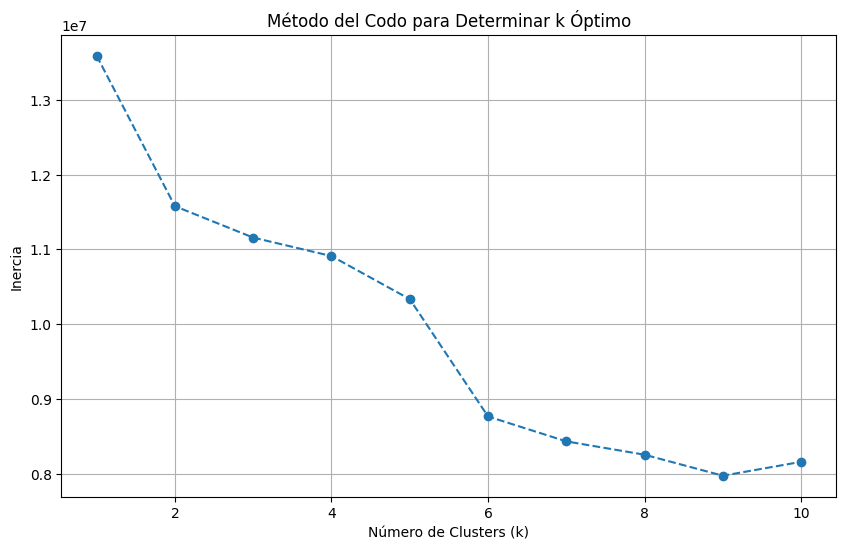

Análisis del Método del Codo completado. Examine el gráfico para identificar el codo.


In [28]:
print("Ejecutando el Método del Codo para determinar el número óptimo de clusters...")

# Definir un rango de k valores
k_range = range(1, 11) # Evaluar de 1 a 10 clusters

# Inicializar lista para almacenar los valores de inercia
inertia = []

# 3. Loop a través del rango de k valores
for k in k_range:
    # a. Crear una instancia de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10, verbose=False)

    # b. Ajustar el modelo a los datos escalados
    mbkmeans.fit(df_clustering_scaled)

    # c. Añadir la inercia del modelo a la lista
    inertia.append(mbkmeans.inertia_)

# 4. Plotear los k valores contra sus valores de inercia
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')

# 5. Añadir un título al plot
plt.title('Método del Codo para Determinar k Óptimo')

# 6. Etiquetar los ejes
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')

# 7. Mostrar el plot
plt.grid(True)
plt.show()

print("Análisis del Método del Codo completado. Examine el gráfico para identificar el codo.")

#### Método de Coeficientes de Silhouette

Calcular el coeficiente de silueta (Silhouette Score) para un rango de valores de 'k' para evaluar la calidad de los clusters. Un valor más cercano a 1 indica clusters bien separados y densos. Se visualizarán los resultados para identificar el número de clusters que maximiza este coeficiente. Para acelerar el proceso, se utilizará una muestra aleatoria del dataset `df_clustering_scaled` (aprox. 10%).


Ejecutando el Método de la Silueta para determinar el número óptimo de clusters (con muestreo)...


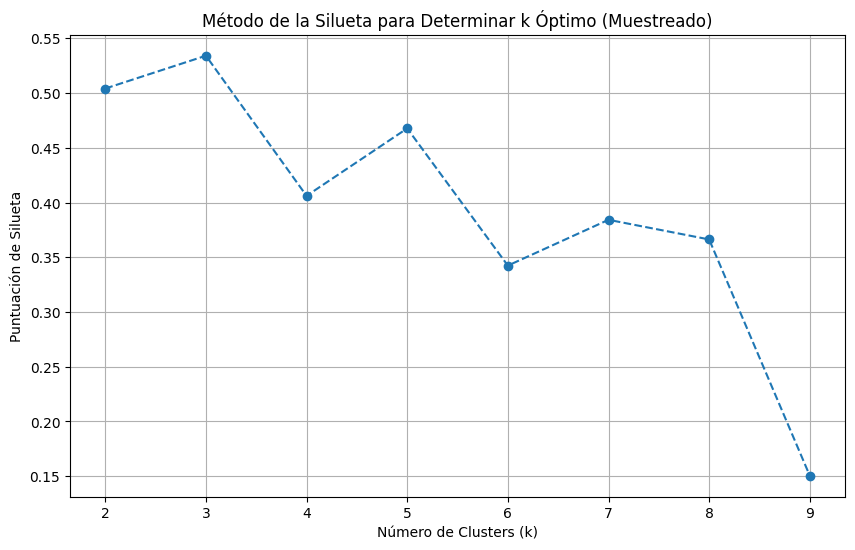

Análisis del Método de la Silueta completado. Examine el gráfico para identificar el k con la puntuación más alta.


In [29]:
print("Ejecutando el Método de la Silueta para determinar el número óptimo de clusters (con muestreo)...")

from sklearn.metrics import silhouette_score

# Definir un rango de valores para k (Silhouette Score no está definido para k=1)
k_range_silhouette = range(2, 10) # Evaluar de 2 a 10 clusters

# 2. Inicializar lista para almacenar los valores de silhouette score
silhouette_scores = []

# Definir el tamaño de la muestra para el cálculo de Silhouette Score
sample_size = 50000 # Un tamaño de muestra razonable para grandes datasets

# Crear una muestra aleatoria del dataset escalado para el cálculo de Silhouette Score
# Esto es crucial para manejar la complejidad O(N^2) del Silhouette Score en grandes datasets.
np.random.seed(42) # Para reproducibilidad
sample_indices = np.random.choice(df_clustering_scaled.shape[0], sample_size, replace=False)
df_clustering_sampled = df_clustering_scaled[sample_indices]

# Loop a través del rango de k valores
for k in k_range_silhouette:
    # Crear una instancia de MiniBatchKMeans
    mbkmeans_silhouette = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10, verbose=False)
    # Ajustar el modelo a la muestra de datos escalados y predecir las etiquetas
    cluster_labels_silhouette = mbkmeans_silhouette.fit_predict(df_clustering_sampled)
    # Calcular el silhouette score
    score = silhouette_score(df_clustering_sampled, cluster_labels_silhouette)
    silhouette_scores.append(score)

# Plotear los k valores contra sus valores de silhouette score
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Método de la Silueta para Determinar k Óptimo (Muestreado)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')
plt.grid(True)
plt.show()

print("Análisis del Método de la Silueta completado. Examine el gráfico para identificar el k con la puntuación más alta.")

Se observa que un valor de K=8 sería un óptimo para

#### Aplicar algoritmo con valor óptimo de k

Aplicar el algoritmo MiniBatchKMeans con el número óptimo de clusters (k=8) al dataset `df_clustering_scaled`. Asignar las etiquetas de cluster resultantes como una nueva característica ('cluster_label') al DataFrame `df_train`.


In [30]:
print("Aplicando MiniBatchKMeans con 8 clusters para segmentación comportamental...")

# 1. Inicializar MiniBatchKMeans con n_clusters=8
n_clusters = 8 # Óptimo k determinado por los métodos del codo y la silueta
mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init=10, verbose=False)

# 2. Ajustar el modelo y obtener las etiquetas de cluster
cluster_labels = mbkmeans.fit_predict(df_clustering_scaled)

# 3. Añadir las etiquetas de cluster como una nueva columna al DataFrame df_train
df_train['cluster_label'] = cluster_labels.astype(np.int8)

print("Segmentación comportamental completada.")
print("Primeras 5 filas del DataFrame con la nueva columna 'cluster_label':")
display(df_train[['TransactionID', 'isFraud', 'cluster_label']].head())
print(f"Distribución de las etiquetas de cluster:\n{df_train['cluster_label'].value_counts()}")

Aplicando MiniBatchKMeans con 8 clusters para segmentación comportamental...
Segmentación comportamental completada.
Primeras 5 filas del DataFrame con la nueva columna 'cluster_label':


,TransactionID,isFraud,cluster_label
0,2987000,0,1
1,2987001,0,1
2,2987002,0,5
3,2987003,0,1
4,2987004,0,1


Distribución de las etiquetas de cluster:
cluster_label
1    273244
5     97688
2     92841
3     56996
6     22778
0     22327
7     12655
4     12011
Name: count, dtype: int64


### 4.3 Visualizar e interpretar clusters

#### Grafico de barras por proporción de isFraud

Calcular la cantidad y porcentaje de transacciones fraudulentas ('isFraud' == 1) y no fraudulentas ('isFraud' == 0) para cada Cluster en el DataFrame `df_train`.


In [32]:
print("Calculando la distribución de transacciones fraudulentas y no fraudulentas por cluster...")

# 1. Agrupar por 'cluster_label' y 'isFraud' y contar ocurrencias
fraud_by_cluster = df_train.groupby(['cluster_label', 'isFraud']).size().unstack(fill_value=0)

# 2. Renombrar columnas para claridad
fraud_by_cluster.rename(columns={0: 'NoFraud_Count', 1: 'Fraud_Count'}, inplace=True)

# 3. Calcular el total de transacciones por cluster
fraud_by_cluster['Total_Transactions'] = fraud_by_cluster['NoFraud_Count'] + fraud_by_cluster['Fraud_Count']

# 4. Calcular el porcentaje de transacciones fraudulentas y no fraudulentas por cluster
fraud_by_cluster['NoFraud_Percentage'] = (fraud_by_cluster['NoFraud_Count'] / fraud_by_cluster['Total_Transactions']) * 100
fraud_by_cluster['Fraud_Percentage'] = (fraud_by_cluster['Fraud_Count'] / fraud_by_cluster['Total_Transactions']) * 100

# 5. Mostrar el resultado
print("Distribución de Fraude por Cluster:")
display(fraud_by_cluster)

print("Análisis de la distribución de fraude por cluster completado.")

Calculando la distribución de transacciones fraudulentas y no fraudulentas por cluster...
Distribución de Fraude por Cluster:


isFraud,NoFraud_Count,Fraud_Count,Total_Transactions,NoFraud_Percentage,Fraud_Percentage
cluster_label,,,,,
0,21212,1115,22327,95.006046,4.993954
1,261028,12216,273244,95.529271,4.470729
2,88435,4406,92841,95.254252,4.745748
3,56430,566,56996,99.006948,0.993052
4,11874,137,12011,98.859379,1.140621
5,96031,1657,97688,98.303783,1.696217
6,22407,371,22778,98.371235,1.628765
7,12460,195,12655,98.459107,1.540893


Análisis de la distribución de fraude por cluster completado.


Generar un gráfico de barras apiladas utilizando el DataFrame `fraud_by_cluster` calculado previamente, para visualizar la distribución del fraude dentro de cada clúster



Visualizando la distribución de fraude por cluster...


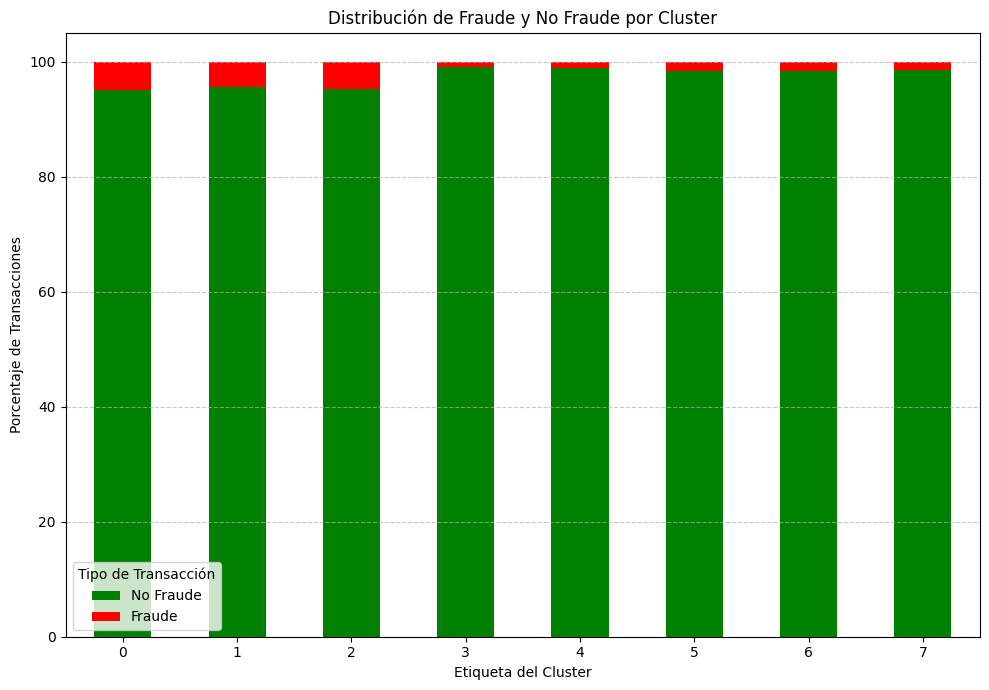

Visualización de la distribución de fraude por cluster completada.


In [33]:
print("Visualizando la distribución de fraude por cluster...")

# Preparar los datos para el gráfico de barras apiladas
plot_df = fraud_by_cluster[['NoFraud_Percentage', 'Fraud_Percentage']]

# Crear el gráfico de barras apiladas
plt.figure(figsize=(10, 7))
plot_df.plot(kind='bar', stacked=True, color={'NoFraud_Percentage': 'green', 'Fraud_Percentage': 'red'}, ax=plt.gca())

plt.title('Distribución de Fraude y No Fraude por Cluster')
plt.xlabel('Etiqueta del Cluster')
plt.ylabel('Porcentaje de Transacciones')
plt.xticks(rotation=0)
plt.legend(['No Fraude', 'Fraude'], title='Tipo de Transacción')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualización de la distribución de fraude por cluster completada.")

### 4.4 Análisis de información de los clusters

**Análisis:**

La visualización revela diferencias significativas en las tasas de fraude entre los clústeres. El clúster 1 presenta una tasa de fraude considerablemente mayor, del 4,24 %, en comparación con el clúster 0, que tiene una tasa del 1,23 %. Esto indica que las transacciones fraudulentas no se distribuyen uniformemente y se concentran en mayor medida en el clúster 1.

* **Clúster 0**: De 145 379 transacciones, 1793 fueron fraudulentas, lo que representa una tasa de fraude de aproximadamente el 1,23 %.

* **Clúster 1**: De 445 161 transacciones, 18 870 fueron fraudulentas, lo que representa una tasa de fraude significativamente mayor, de aproximadamente el 4,24 %.

* **Distribución desigual del fraude**: El clúster 1 presenta una tasa de fraude más de tres veces superior a la del clúster 0, lo que indica un patrón claro donde el fraude se concentra en segmentos específicos de transacciones.


**Conclusiones o Próximos Pasos:**
* **Detección Dirigida de Fraude**: La mayor tasa de fraude en el Clúster 1 sugiere que los modelos o estrategias de detección de fraude deberían adaptarse específicamente o aplicarse con mayor rigor a las transacciones pertenecientes a este clúster para maximizar la eficiencia.

* **Investigación de las Características del Clúster**: Se debería realizar un análisis más profundo para comprender las características distintivas (p. ej., tipo de transacción, importe, hora, comportamiento del usuario) de las transacciones dentro del Clúster 1 que contribuyen a su elevada tasa de fraude, lo que podría servir de base para reglas de prevención de fraude más precisas.
